#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час.

**Формирование задачи**

На основании исторических данных о заказах такси в аэропортах необходимо спрогнозировать количество заказов такси на следующий час.  Необходимо построить модель для такого предсказания.В качестве метрики используем RMSE. Значение метрики RMSE на тестовой выборке должно быть не больше 48.

**План исследования**

1. Загрузка и предообработка данных
2. Исследовательский анализ данных
3. Ресемплирование по одному часу
4. Анализ сезонной составляющей, тренда и остатков декомпозиции
5. Подготовка данных
6. Обучение разных моделей с различными гиперпараметрами.
7. Проверка данных на тестовой выборке

**Описание данных**

**num_orders** — количество заказов такси

## Загрузка данных

In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
!pip install lightgbm -q
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
RANDOM_STATE = 42

In [2]:
#считаем csv - файл с данными `taxi.csv`
try:
    taxi = pd.read_csv('taxi.csv')
except:
    taxi = pd.read_csv('https://code.s3.yandex.net/datasets/taxi.csv')

In [3]:
display(taxi.head(10))

,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32
5,2018-03-01 00:50:00,21
6,2018-03-01 01:00:00,7
7,2018-03-01 01:10:00,5
8,2018-03-01 01:20:00,17
9,2018-03-01 01:30:00,12


In [4]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


<div style="border:solid green 2px; padding: 20px">
Вывод: на первом этапе был открыт файл с данными, были выведены первые строки датафрейма. Уже можно отметить, что пропусков нет.

## Предобработка данных

### Общий анализ данных

In [5]:
def desc_data(data): #создадим функцию для описания датасета
    display(data.head(10)) 
    list_c = data.columns
    print(data.info())
    print('-'* 25)
    print('Количество полных дубликатов ', data.duplicated().sum())
    for col_l in list_c:
        print('-'* 25)
        print(col_l,': кол-во NaN',data[col_l].isna().sum(),\
              ', процент NaN', round(data[col_l].isna().mean()*100,2),'%')
        print(data[col_l].describe())

In [6]:
desc_data(taxi)

,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32
5,2018-03-01 00:50:00,21
6,2018-03-01 01:00:00,7
7,2018-03-01 01:10:00,5
8,2018-03-01 01:20:00,17
9,2018-03-01 01:30:00,12


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB
None
-------------------------
Количество полных дубликатов  0
-------------------------
datetime : кол-во NaN 0 , процент NaN 0.0 %
count                   26496
unique                  26496
top       2018-08-15 07:50:00
freq                        1
Name: datetime, dtype: object
-------------------------
num_orders : кол-во NaN 0 , процент NaN 0.0 %
count    26496.000000
mean        14.070463
std          9.211330
min          0.000000
25%          8.000000
50%         13.000000
75%         19.000000
max        119.000000
Name: num_orders, dtype: float64


### Удаление дубликатов

Дубликаты отсутствуют.

### Изменение формата данных

Изменим формат данных столбца 'datetime' на datetime64.

In [7]:
taxi['datetime'] = taxi['datetime'].astype('datetime64[ns]')

In [8]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    26496 non-null  datetime64[ns]
 1   num_orders  26496 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 414.1 KB


### Проверка уникальных значений

Все значения столбца 'datetime' уникальны.

### Удаление ненужных признаков

Удаление ненужных признаков не требуется.

<div style="border:solid green 2px; padding: 20px">
Вывод: на втором этапе была проведена предобработка данных. Дубликаты отсутствуют. Изменен формат данных столбца 'datetime'.

## Исследовательский анализ данных

### Исследование количественных признаков

In [9]:
taxi.drop('datetime',axis=1).describe().T

,count,mean,std,min,25%,50%,75%,max
num_orders,26496.0,14.070463,9.21133,0.0,8.0,13.0,19.0,119.0


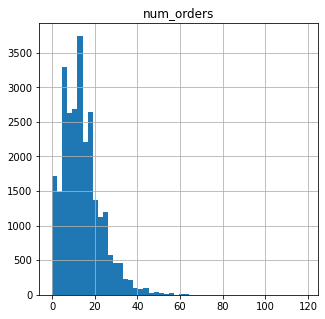

In [10]:
taxi.drop('datetime',axis=1).hist(figsize=(5, 5),bins=50);

In [11]:
def hist_plot(data,index,bins):
    plt.figure(figsize=(20, 5))
    plt.suptitle('Гистограмма и диаграмма размаха для показателя "' + index+'"', fontsize=20, y=1.05)
        
    
    plt.subplot(1, 2, 1)
    mean = np.mean(data[index])
    median = np.median(data[index])
    sns.histplot(data[index], bins=bins, kde=True, color='skyblue')
    plt.axvline(mean, color='r', linestyle='dashed', linewidth=1, label=f'Среднее: {mean:.2f}')
    plt.axvline(median, color='g', linestyle='dashed', linewidth=1, label=f'Медиана: {median:.2f}');
    plt.ylabel('Количество показателей')
    plt.title('Гистограмма по значению ' + index, fontsize=16)
    plt.legend()
    plt.xlabel(index);
    
    plt.subplot(1, 2, 2)
    ax = sns.boxplot(y=index, data=data)
    plt.title('Boxplot для показателя ' + index, fontsize=16)
    plt.axhline(y=mean, color='g', linestyle='--')
    plt.ylabel(index, fontsize=14);
    plt.show()

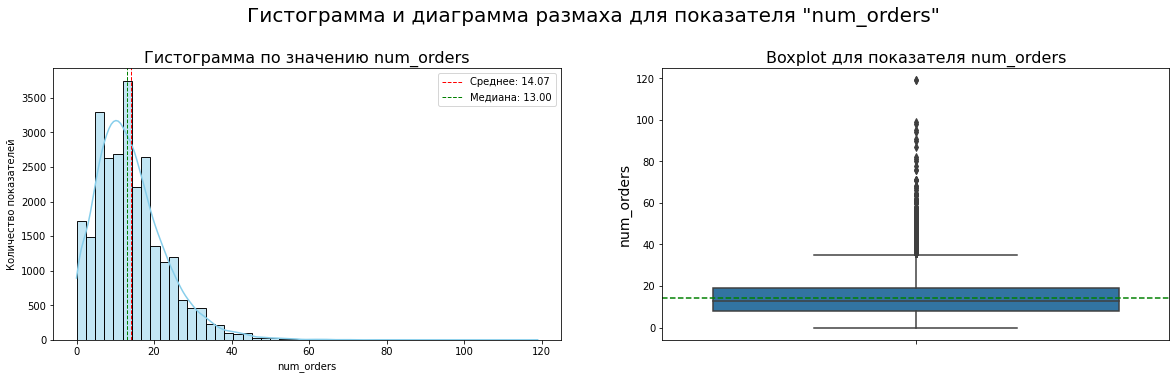

In [12]:
hist_plot(taxi,'num_orders',50)

### Исследование временных признаков

In [13]:
taxi_time=taxi.copy()
taxi_time['year'] = pd.DatetimeIndex(taxi_time['datetime']).year
taxi_time['datetime'] = pd.to_datetime(taxi_time['datetime']).dt.normalize()
taxi_time['month'] = taxi_time['datetime'].dt.month_name()
taxi_time['day'] = taxi_time['datetime'].dt.day_name()
taxi_time['hour'] = pd.to_datetime(taxi['datetime']).dt.strftime("%H")
print('Уникальные значение года в столбце datetime:',taxi_time['year'].unique())
print('Уникальные значение месяца в столбце datetime:',taxi_time['month'].unique())
print('Уникальные значения дня недели в столбце datetime:',taxi_time['day'].unique())
print('Уникальные значения часа в столбце datetime',taxi_time['hour'].unique())

Уникальные значение года в столбце datetime: [2018]
Уникальные значение месяца в столбце datetime: ['March' 'April' 'May' 'June' 'July' 'August']
Уникальные значения дня недели в столбце datetime: ['Thursday' 'Friday' 'Saturday' 'Sunday' 'Monday' 'Tuesday' 'Wednesday']
Уникальные значения часа в столбце datetime ['00' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '11' '12' '13'
 '14' '15' '16' '17' '18' '19' '20' '21' '22' '23']


Проанализируем количество заказов такси по месяцам и дням.

In [14]:
def rasp_time(name,size,pad):
    table = taxi_time.pivot_table(index=name, values='num_orders', aggfunc='sum').\
    sort_values(by='num_orders',ascending=False).reset_index()
    display(table)
    plt.title('Распределение объема заказов по категории '+name, fontsize=15, pad=pad)
    plt.pie(table['num_orders'].unique(), autopct='%1.1f%%',radius = size)
    plt.legend(title=name, loc="center right", bbox_to_anchor = (1,0,1,1), labels = table[name].unique());

,month,num_orders
0,August,94973
1,July,74405
2,June,59906
3,May,54820
4,April,45939
5,March,42768


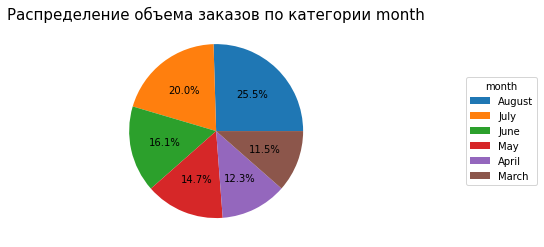

In [15]:
rasp_time('month',1,0)

,day,num_orders
0,Friday,59059
1,Monday,56314
2,Thursday,55508
3,Saturday,52321
4,Wednesday,52263
5,Sunday,49291
6,Tuesday,48055


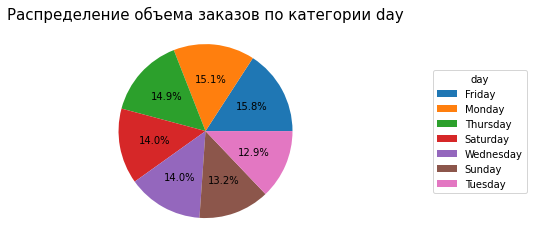

In [16]:
rasp_time('day',1,0)

,hour,num_orders
0,00,26570
1,16,21003
2,02,20805
3,23,20197
4,01,19203
5,03,18772
6,22,18124
7,21,17519
8,10,17134
9,17,17061


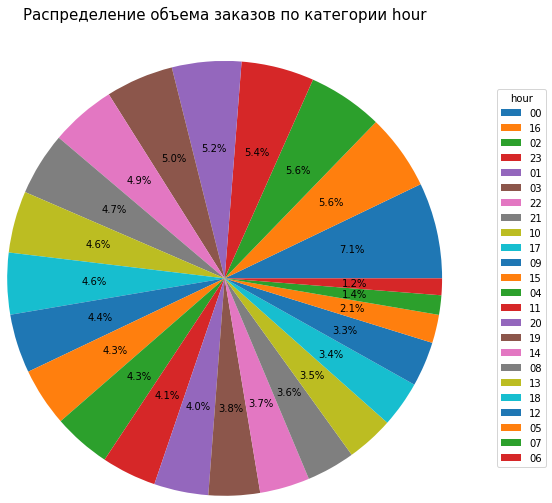

In [17]:
rasp_time('hour',2.5,150)

Установим индекс таблицы равным столбцу datetime.

In [18]:
taxi.set_index('datetime', inplace=True)
taxi.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


Построим график временного ряда.

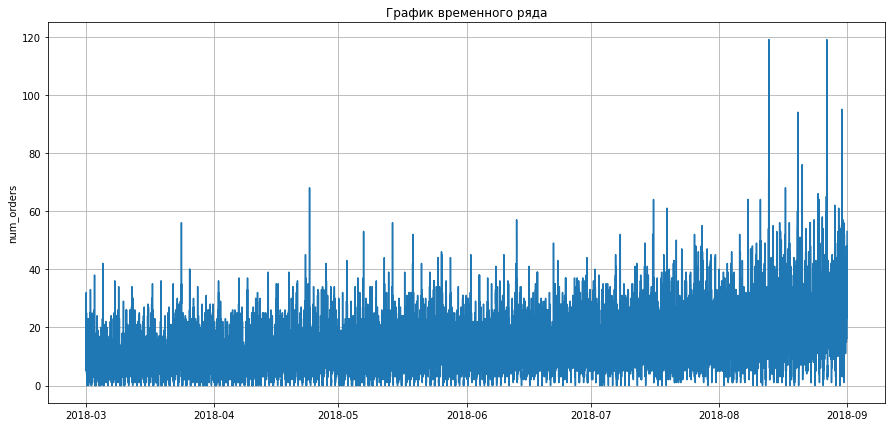

In [19]:
plt.figure(figsize=(15, 7))
plt.plot(taxi)
plt.title('График временного ряда')
plt.grid(True)
plt.ylabel('num_orders')
plt.show();

<div style="border:solid green 2px; padding: 20px">
Вывод: на третьем этапе был проведен исследовательский анализ данных. Выбросов не наблюдается. Наибольший объем заказов наблюдается в апреле. По дням распределением объема заказов относительно равномерное, но лидируют пятница и понедельник. Лидером по часу заказов - первый час дня. Построен график временного ряда.

## Ресемплирование по одному часу

Ресемплируем данные по 1 часу.

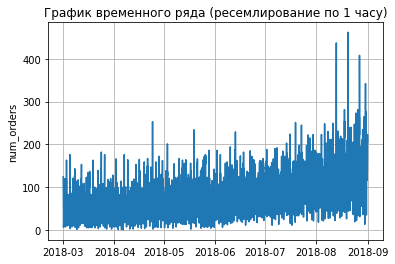

In [20]:
taxi_hour = taxi.resample('1H').sum()
plt.plot(taxi_hour)
plt.title('График временного ряда (ресемлирование по 1 часу)')
plt.grid(True)
plt.ylabel('num_orders')
plt.show();

In [21]:
taxi_hour.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


Добавим график скользящего среднего.

In [22]:
taxi_hour['rolling_mean'] = taxi_hour.rolling(24).mean()
taxi_hour.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num_orders    4416 non-null   int64  
 1   rolling_mean  4393 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 103.5 KB


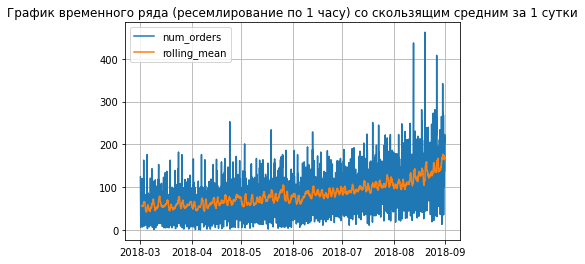

In [23]:
plt.plot(taxi_hour)
plt.title('График временного ряда (ресемлирование по 1 часу) со скользящим средним за 1 сутки')
plt.grid(True)
plt.legend(taxi_hour.columns)
plt.show();

<div style="border:solid green 2px; padding: 20px">
Вывод: на четвертом этапе было проведено ресемплирование по 1 часу и добавлен график скользящего среднего за 1 сутки.

## Анализ сезонной составляющей, тренда и остатков декомпозиции

### Анализ сезонной составляющей, тренда и остатков декомпозиции по дням

In [24]:
taxi_day = taxi.resample('1D').sum()
taxi_day.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 184 entries, 2018-03-01 to 2018-08-31
Freq: D
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  184 non-null    int64
dtypes: int64(1)
memory usage: 2.9 KB


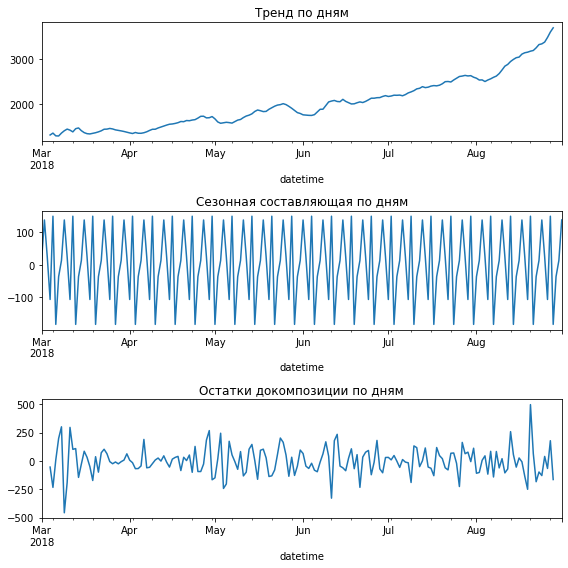

In [25]:
decomposed = seasonal_decompose(taxi_day)
plt.figure(figsize=(8, 8))
plt.subplot(311)
# Чтобы график корректно отобразился, указываем его
# оси ax, равными plt.gca() (англ. get current axis,
# получить текущие оси)
decomposed.trend.plot(ax=plt.gca())
plt.title('Тренд по дням')
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
    
plt.title('Сезонная составляющая по дням')
plt.subplot(313)

decomposed.resid.plot(ax=plt.gca())
plt.title('Остатки докомпозиции по дням')
plt.tight_layout()

Проанализируем данные сезонной составляющей за март отдельно.

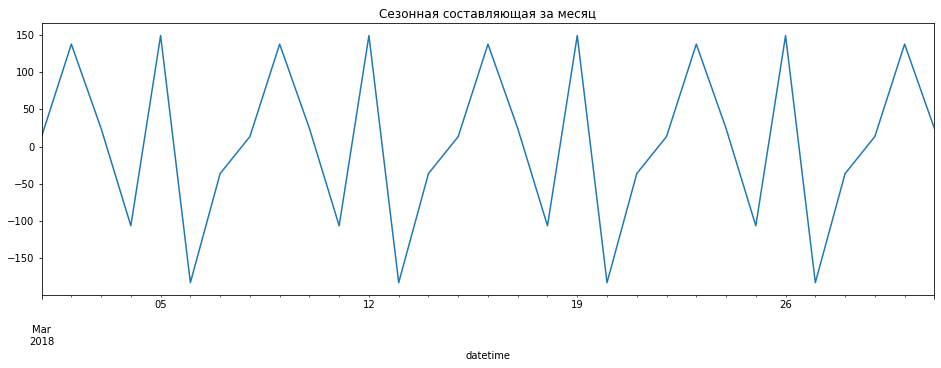

In [26]:
plt.figure(figsize=(16, 5))
decomposed.seasonal['2018-03-01':'2018-03-31'].plot(ax=plt.gca())
plt.title('Сезонная составляющая за месяц');

05 марта 2018 года был понедельником. Т.е. фактически подтверждается тренд, продемонстрированный на круговой диаграмме. Наибольшее количество заказов приходится на пятницу и понедельник, а наименьшее - на воскресенье и вторник.

### Анализ сезонной составляющей, тренда и остатков декомпозиции по часам

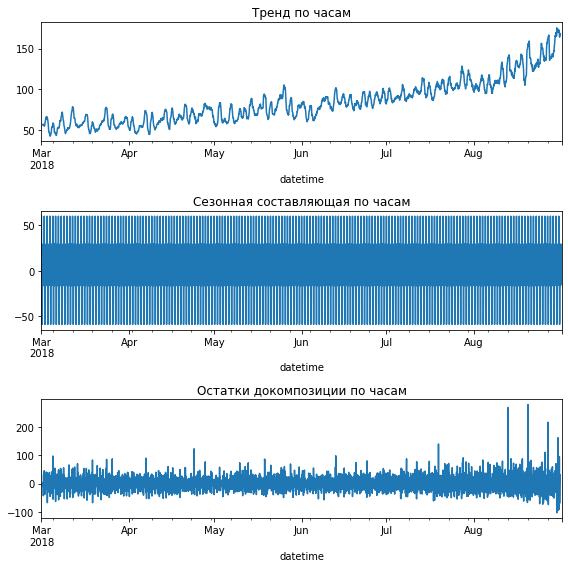

In [27]:
decomposed = seasonal_decompose(taxi_hour.drop('rolling_mean',axis=1))
plt.figure(figsize=(8, 8))
plt.subplot(311)
# Чтобы график корректно отобразился, указываем его
# оси ax, равными plt.gca() (англ. get current axis,
# получить текущие оси)
decomposed.trend.plot(ax=plt.gca())
plt.title('Тренд по часам')
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
    
plt.title('Сезонная составляющая по часам')
plt.subplot(313)

decomposed.resid.plot(ax=plt.gca())
plt.title('Остатки докомпозиции по часам')
plt.tight_layout()

Выведем данные за первые два дня марта.

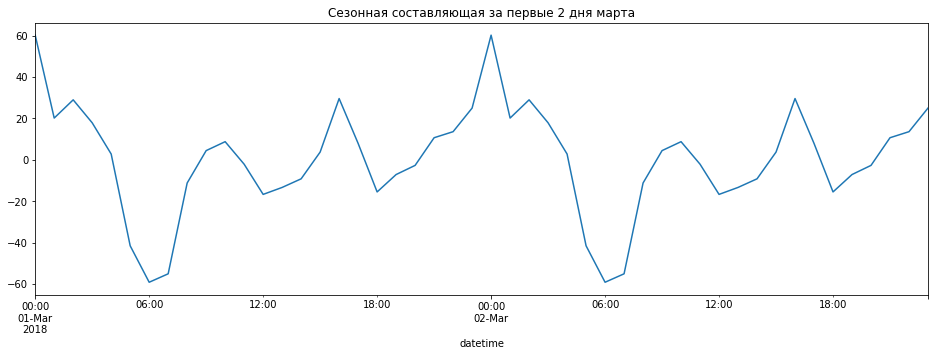

In [28]:
plt.figure(figsize=(16, 5))
decomposed.seasonal['2018-03-01':'2018-03-02'].plot(ax=plt.gca())
plt.title('Сезонная составляющая за первые 2 дня марта');

Подтверждается тренд, продемонстрированный на круговой диаграмме. Наибольшее количество заказов приходится на первый час дня, а наименьшее - на седьмой час.

<div style="border:solid green 2px; padding: 20px">
Вывод: на пятом этапе был проведен анализ сезонности заказов такси по часам и дням недели.

## Подготовка данных

Напишем функцию make_features() (англ. «создать признаки»), чтобы прибавить к таблице четыре новых календарных признака: год, месяц, день и день недели. Для поиска разностей временного ряда применим метод shift() (англ. «сдвиг»). Вычислим скользящее среднее и добавьте его как признак 'rolling_mean'.

In [29]:
def make_features(data,max_lag,rolling_mean_size):
    copy = data.copy()
    copy['month'] = copy.index.month
    copy['day'] = copy.index.day
    copy['dayofweek'] = copy.index.dayofweek
    for lag in range(1, max_lag + 1):
        copy['lag_{}'.format(lag)] = copy['num_orders'].shift(lag)

    copy['rolling_mean'] = copy['num_orders'].rolling(rolling_mean_size).mean().shift()
    return copy

In [30]:
def train_test(data): #функция разбиения на тренировочную и тестовую выборки
    train, test = train_test_split(data, shuffle=False, test_size=0.1)
    train = train.dropna()

    X_train = train.drop(columns='num_orders')
    y_train = train['num_orders']
    X_test = test.drop(columns='num_orders')
    y_test = test['num_orders']
    return X_train,y_train,X_test,y_test

<div style="border:solid green 2px; padding: 20px">
Вывод: на шестом этапе были составлены две функции для подготовки данных.

## Обучение моделей

Для обучения были выбраны 4 модели:

- LinearRegression()
- DecisionTreeRegressor()
- KNeighborsRegressor()
- LGBMRegressor()

In [31]:
col_dan_model = ['max_lag','rolling_mean_size','модель','лучшие_параметры','RMSE на обучающей выборке']

In [32]:
dan_model = pd.DataFrame(columns=col_dan_model)

Создадим функцию по обучению и добавлению строки в итоговую таблицу результатов обучения.

In [33]:
def param_model(model,params,max_lag,rolling_mean_size):
    global dan_model, gs
    # инициализирование модели
    model = model

    # подбираем параметры
    param_grid = params

    ts_cv = TimeSeriesSplit(n_splits=5)
    
    gs = GridSearchCV(
        model,
        param_grid,
        cv=ts_cv,
        n_jobs=-1,
        scoring='neg_root_mean_squared_error'
    )
    gs.fit(X_train, y_train)
    new_row = {'max_lag': max_lag,
               'rolling_mean_size': rolling_mean_size,
               'модель':model,
               'лучшие_параметры': gs.best_params_,
               'RMSE на обучающей выборке':round(gs.best_score_*-1,2)}    
    dan_model = dan_model.append(new_row, ignore_index=True)

In [34]:
taxi_hour.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num_orders    4416 non-null   int64  
 1   rolling_mean  4393 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 103.5 KB


In [35]:
list_model = ['LinearRegression','DecisionTreeRegressor','KNeighborsRegressor','LGBMRegressor']

In [36]:
for i in range(28,31):
    for n in range(10,13):
        max_lag = i
        rolling_mean_size = n
        copy = make_features(taxi_hour.drop('rolling_mean',axis=1),i,n)
        X_train,y_train,X_test,y_test = train_test(copy)
        for mod in list_model:
            #модель LinearRegression()
            if mod=='LinearRegression':
                model = LinearRegression()
                params = {'fit_intercept': [True,False]}
                param_model(model,params,max_lag,rolling_mean_size)
            #модель DecisionTreeRegressor()
            if mod=='DecisionTreeRegressor':
                model = DecisionTreeRegressor()
                params = {'max_depth': range(2, 5),
                          'min_samples_leaf': range(2,5),
                          'random_state':[RANDOM_STATE]}
                param_model(model,params,max_lag,rolling_mean_size)
            #модель KNeighborsRegressor()
            if mod=='KNeighborsRegressor':
                model = KNeighborsRegressor()
                params = {'n_neighbors': range(1,501,100),
                          'metric':['euclidean', 'manhattan']}
                param_model(model,params,max_lag,rolling_mean_size)
            #модель LGBMRegressor()
            if mod=='LGBMRegressor':
                model = lgb.LGBMRegressor()   
                params = {'num_leaves': [20,100],
                          'n_estimators': [100,150],
                          'random_state':[RANDOM_STATE]}
                param_model(model,params,max_lag,rolling_mean_size)
            
pd.set_option('max_colwidth', 120)
pd.set_option('display.width', 500)
pd.set_option('display.max_rows', None)
display(dan_model.sort_values(by = 'RMSE на обучающей выборке'))
print(dan_model.shape)

,max_lag,rolling_mean_size,модель,лучшие_параметры,RMSE на обучающей выборке
19,29,11,LGBMRegressor(),"{'n_estimators': 150, 'num_leaves': 20, 'random_state': 42}",25.38
23,29,12,LGBMRegressor(),"{'n_estimators': 100, 'num_leaves': 20, 'random_state': 42}",25.41
31,30,11,LGBMRegressor(),"{'n_estimators': 100, 'num_leaves': 20, 'random_state': 42}",25.42
35,30,12,LGBMRegressor(),"{'n_estimators': 150, 'num_leaves': 20, 'random_state': 42}",25.43
15,29,10,LGBMRegressor(),"{'n_estimators': 100, 'num_leaves': 20, 'random_state': 42}",25.50
7,28,11,LGBMRegressor(),"{'n_estimators': 150, 'num_leaves': 20, 'random_state': 42}",25.58
3,28,10,LGBMRegressor(),"{'n_estimators': 100, 'num_leaves': 20, 'random_state': 42}",25.61
11,28,12,LGBMRegressor(),"{'n_estimators': 100, 'num_leaves': 20, 'random_state': 42}",25.63
27,30,10,LGBMRegressor(),"{'n_estimators': 100, 'num_leaves': 20, 'random_state': 42}",25.66
32,30,12,LinearRegression(),{'fit_intercept': True},26.50


(36, 5)


<div style="border:solid green 2px; padding: 20px">
Вывод: на седьмом этапе были обучены 4 модели с подбором параметров. Наилучшая метрика получена при применении модели LGBMRegressor(num_leaves = 20, n_estimators = 150, random_state=42). Размер отставания - 29. Скользящее среднее - 11.

## Проверка данных на тестовой выборке

In [37]:
taxi_hour.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num_orders    4416 non-null   int64  
 1   rolling_mean  4393 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 103.5 KB


In [38]:
make_features(taxi_hour,29,11)
train_test(taxi_hour.drop('rolling_mean',axis=1))
model = lgb.LGBMRegressor(num_leaves = 20, n_estimators = 150, random_state=RANDOM_STATE)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
rmse = math.sqrt(mean_squared_error(predictions, y_test))    
print('RMSE для модели LightGBM:',round(rmse,2))

RMSE для модели LightGBM: 42.68


Построим два временных ряда на одном графике для тестовой выборки.

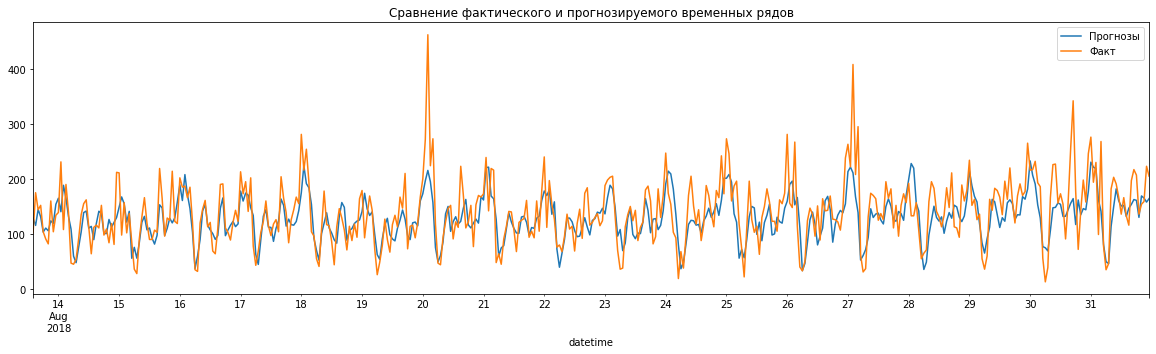

In [39]:
table_for_graf = pd.DataFrame({'Прогнозы':predictions,'Факт':y_test})
table_for_graf.plot(figsize=(20,5))
plt.title('Сравнение фактического и прогнозируемого временных рядов')
plt.show()

<div style="border:solid green 2px; padding: 20px">
Вывод: на восьмом этапе была проведена проверка модели на тестовой выборке. Результат метрики соответствует условию (RMSE менее 48). Размер отставания - 29. Скользящее среднее - 11. Метрика для тестовой выборки - 42.68.

## Общий вывод

<div style="border:solid green 2px; padding: 20px">
Вывод: в рамках проекта были выполнены следующие этапы:
    
- Загрузка и предообработка данных
- Исследовательский анализ данных
- Ресемплирование по одному часу
- Анализ сезонной составляющей, тренда и остатков декомпозиции
- Подготовка данных
- Обучение разных моделей с различными гиперпараметрами
- Проверка данных на тестовой выборке.
    
Метрика RMSE для модели LGBMRegressor(num_leaves = 20, n_estimators = 150, random_state=42) составила 42.68 (на тестовой выборке). Размер отставания - 29. Скользящее среднее - 11.